# Loading Libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

# Grouped Column Charts for All Regions

Data preparation and currency conversions

In [12]:
# Load data
df = pd.read_csv("data/regional_GDP_per_capita.csv")
df2 = pd.read_csv("data/regional_GDP.csv")

# Compute YoY Growth
df2["YoY_Growth"] = (df2["2024"]/df2["2022"]) ** (1/2) - 1
df2["YoY_Growth"] = df2["YoY_Growth"].round(4)

# Filter for GDP per capita
ncr_per_capita = df[df["Region"] == "National Capital Region"]
phil_per_capita = df[df["Region"] == "Philippines"]
luzon_per_capita = df[df["Region"] == "Central Luzon"]
calabarzon_per_capita = df[df["Region"] == "CALABARZON"]
visayas_per_capita = df[df["Region"] == "Central Visayas"]

# Convert GDP per capita values to USD
NCR_GDP_per_capita = (ncr_per_capita["2024"]).round(2).tolist()
Philippines_GDP_per_capita = (phil_per_capita["2024"]).round(2).tolist()
Luzon_GDP_per_capita = (luzon_per_capita["2024"]).round(2).tolist()
Calabarzon_GDP_per_capita = (calabarzon_per_capita["2024"]).round(2).tolist()
Visayas_GDP_per_capita = (visayas_per_capita["2024"]).round(2).tolist()

# Filter for GDP YoY Growth
ncr_growth = df2[df2["Region"] == "National Capital Region"]
phil_growth = df2[df2["Region"] == "Philippines"]
luzon_growth = df2[df2["Region"] == "Central Luzon"]
calabarzon_growth = df2[df2["Region"] == "CALABARZON"]
visayas_growth = df2[df2["Region"] == "Central Visayas"]

# Get growth values
NCR_GDP_growth = ncr_growth["YoY_Growth"].values.flatten().tolist()
Philippines_GDP_growth = phil_growth["YoY_Growth"].values.flatten().tolist()
Luzon_GDP_growth = luzon_growth["YoY_Growth"].values.flatten().tolist()
Calabarzon_GDP_growth = calabarzon_growth["YoY_Growth"].values.flatten().tolist()
Visayas_GDP_growth = visayas_growth["YoY_Growth"].values.flatten().tolist()

## NCR vs. Philippines

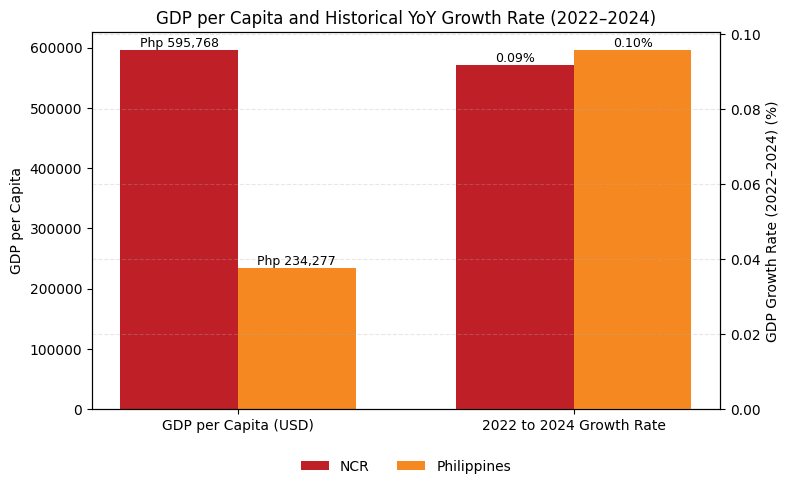

In [17]:
# Bar width and plot size
width = 0.35
categories = ["GDP per Capita (USD)", "2022 to 2024 Growth Rate"]
x = np.arange(len(categories))

fig, ax1 = plt.subplots(figsize=(8, 5))

# GDP per Capita Bars
bars1 = ax1.bar(x[0] - width/2, NCR_GDP_per_capita, width, label="NCR", color='#bf1f26')
bars2 = ax1.bar(x[0] + width/2, Philippines_GDP_per_capita, width, label="Philippines", color='#f58820ff')

# GDP YoY Growth bars
ax2 = ax1.twinx()
bars3 = ax2.bar(x[1] - width/2, NCR_GDP_growth, width, color='#bf1f26')
bars4 = ax2.bar(x[1] + width/2, Philippines_GDP_growth, width, color='#f58820ff')

# GDP per Capita Label
ax1.set_ylabel("GDP per Capita")

# GDP Growth Rate label
ax2.set_ylabel("GDP Growth Rate (2022–2024) (%)")

# Function for the bar labels
def add_labels(ax, bar_container, fmt="{:,.0f}"):
    for b in bar_container.patches:
        val = b.get_height()
        ax.annotate(fmt.format(val),
                    xy=(b.get_x() + b.get_width()/2, val),
                    xytext=(0, 0), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

# Add labels
add_labels(ax1, bars1, fmt="Php {:,.0f}")
add_labels(ax1, bars2, fmt="Php {:,.0f}")
add_labels(ax2, bars3, fmt="{:.2f}%")
add_labels(ax2, bars4, fmt="{:.2f}%")

# Legend
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# ax1 ticks
#ax1.set_ylim(0, 11500)
#ax1.set_yticks([0, 2000, 4000, 6000, 8000, 10000])

# ax2 ticks
#ax2.set_ylim(0, 28.8)
#ax2.set_yticks([0, 5, 10, 15, 20, 25])

# grid
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_xticks(x, categories)
ax1.set_title("GDP per Capita and Historical YoY Growth Rate (2022–2024)")

# show graph
plt.tight_layout()
plt.show()

## Central Luzon vs. NCR

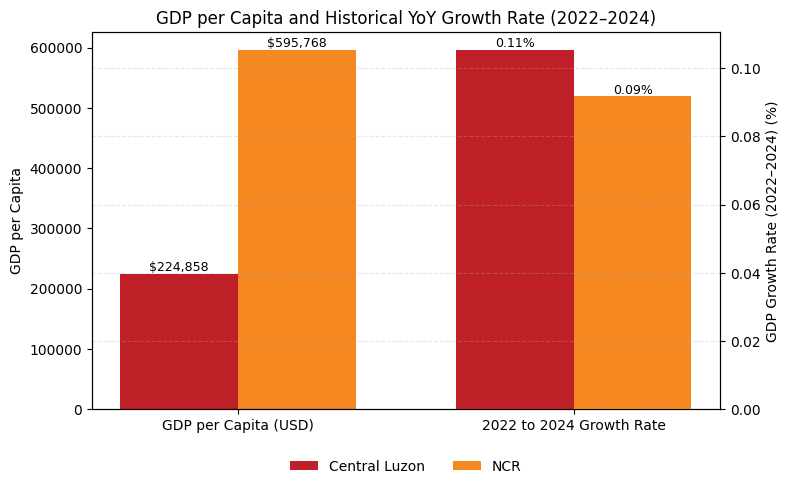

In [20]:
# Bar width and plot size
width = 0.35
categories = ["GDP per Capita (USD)", "2022 to 2024 Growth Rate"]
x = np.arange(len(categories))

fig, ax1 = plt.subplots(figsize=(8, 5))

# GDP per Capita Bars
bars1 = ax1.bar(x[0] - width/2, Luzon_GDP_per_capita, width, label="Central Luzon", color='#bf1f26')
bars2 = ax1.bar(x[0] + width/2, NCR_GDP_per_capita, width, label="NCR", color='#f58820ff')

# GDP YoY Growth bars
ax2 = ax1.twinx()
bars3 = ax2.bar(x[1] - width/2, Luzon_GDP_growth, width, color='#bf1f26')
bars4 = ax2.bar(x[1] + width/2, NCR_GDP_growth, width, color='#f58820ff')

# GDP per Capita Label
ax1.set_ylabel("GDP per Capita")

# GDP Growth Rate label
ax2.set_ylabel("GDP Growth Rate (2022–2024) (%)")

# Function for the bar labels
def add_labels(ax, bar_container, fmt="{:,.0f}"):
    for b in bar_container.patches:
        val = b.get_height()
        ax.annotate(fmt.format(val),
                    xy=(b.get_x() + b.get_width()/2, val),
                    xytext=(0, 0), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

# Add labels
add_labels(ax1, bars1, fmt="${:,.0f}")
add_labels(ax1, bars2, fmt="${:,.0f}")
add_labels(ax2, bars3, fmt="{:.2f}%")
add_labels(ax2, bars4, fmt="{:.2f}%")

# Legend
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# # ax1 ticks
# ax1.set_ylim(0, 11500)
# ax1.set_yticks([0, 2000, 4000, 6000, 8000, 10000])

# # ax2 ticks
# ax2.set_ylim(0, 28.8)
# ax2.set_yticks([0, 5, 10, 15, 20, 25])

# grid
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_xticks(x, categories)
ax1.set_title("GDP per Capita and Historical YoY Growth Rate (2022–2024)")

# show graph
plt.tight_layout()
plt.show()


## Calabarzon vs. NCR

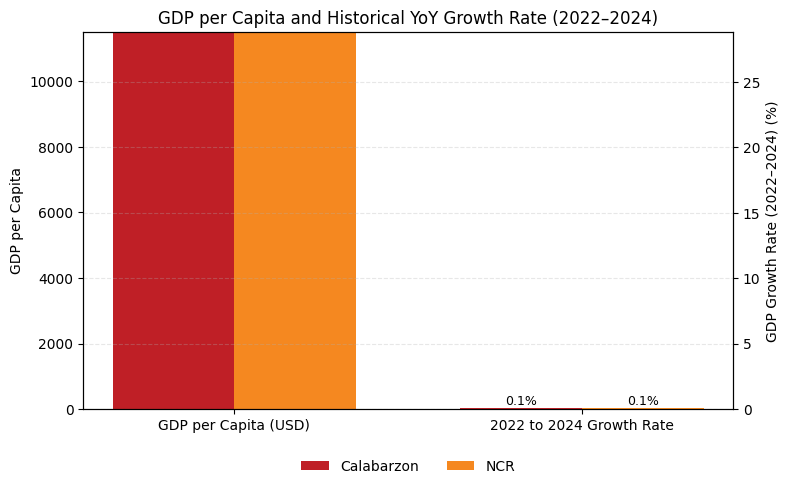

In [21]:
# Bar width and plot size
width = 0.35
categories = ["GDP per Capita (USD)", "2022 to 2024 Growth Rate"]
x = np.arange(len(categories))

fig, ax1 = plt.subplots(figsize=(8, 5))

# GDP per Capita Bars
bars1 = ax1.bar(x[0] - width/2, Calabarzon_GDP_per_capita, width, label="Calabarzon", color='#bf1f26')
bars2 = ax1.bar(x[0] + width/2, NCR_GDP_per_capita, width, label="NCR", color='#f58820ff')

# GDP YoY Growth bars
ax2 = ax1.twinx()
bars3 = ax2.bar(x[1] - width/2, Calabarzon_GDP_growth, width, color='#bf1f26')
bars4 = ax2.bar(x[1] + width/2, NCR_GDP_growth, width, color='#f58820ff')

# GDP per Capita Label
ax1.set_ylabel("GDP per Capita")

# GDP Growth Rate label
ax2.set_ylabel("GDP Growth Rate (2022–2024) (%)")

# Function for the bar labels
def add_labels(ax, bar_container, fmt="{:,.0f}"):
    for b in bar_container.patches:
        val = b.get_height()
        ax.annotate(fmt.format(val),
                    xy=(b.get_x() + b.get_width()/2, val),
                    xytext=(0, 0), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

# Add labels
add_labels(ax1, bars1, fmt="${:,.0f}")
add_labels(ax1, bars2, fmt="${:,.0f}")
add_labels(ax2, bars3, fmt="{:.1f}%")
add_labels(ax2, bars4, fmt="{:.1f}%")

# Legend
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# ax1 ticks
ax1.set_ylim(0, 11500)
ax1.set_yticks([0, 2000, 4000, 6000, 8000, 10000])

# ax2 ticks
ax2.set_ylim(0, 28.8)
ax2.set_yticks([0, 5, 10, 15, 20, 25])

# grid
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_xticks(x, categories)
ax1.set_title("GDP per Capita and Historical YoY Growth Rate (2022–2024)")

# show graph
plt.tight_layout()
plt.show()



## Central Visayas vs. NCR

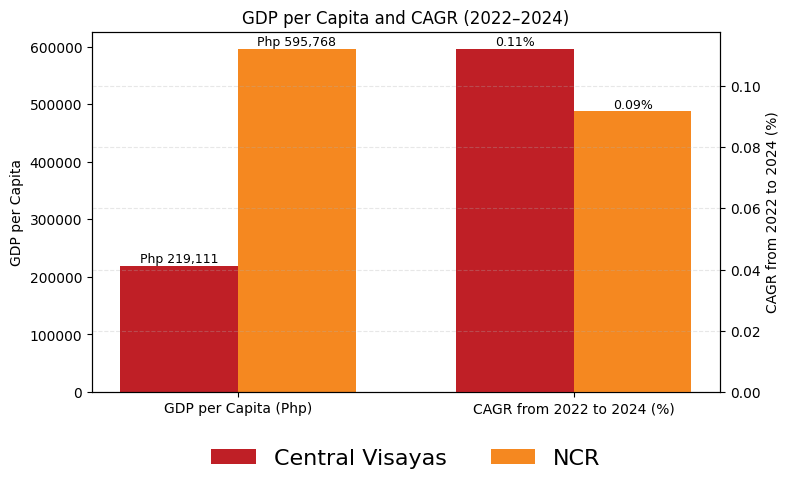

In [33]:
# Bar width and plot size
width = 0.35
categories = ["GDP per Capita (Php)", "CAGR from 2022 to 2024 (%)"]
x = np.arange(len(categories))

fig, ax1 = plt.subplots(figsize=(8, 5))

# GDP per Capita Bars
bars1 = ax1.bar(x[0] - width/2, Visayas_GDP_per_capita, width, label="Central Visayas", color='#bf1f26')
bars2 = ax1.bar(x[0] + width/2, NCR_GDP_per_capita, width, label="NCR", color='#f58820ff')

# GDP YoY Growth bars
ax2 = ax1.twinx()
bars3 = ax2.bar(x[1] - width/2, Visayas_GDP_growth, width, color='#bf1f26')
bars4 = ax2.bar(x[1] + width/2, NCR_GDP_growth, width, color='#f58820ff')

# GDP per Capita Label
ax1.set_ylabel("GDP per Capita")

# GDP Growth Rate label
ax2.set_ylabel("CAGR from 2022 to 2024 (%)")

# Function for the bar labels
def add_labels(ax, bar_container, fmt="{:,.0f}"):
    for b in bar_container.patches:
        val = b.get_height()
        ax.annotate(fmt.format(val),
                    xy=(b.get_x() + b.get_width()/2, val),
                    xytext=(0, 0), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

# Add labels
add_labels(ax1, bars1, fmt="Php {:,.0f}")
add_labels(ax1, bars2, fmt="Php {:,.0f}")
add_labels(ax2, bars3, fmt="{:.2}%")
add_labels(ax2, bars4, fmt="{:.2f}%")

# Legend
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False,
    fontsize=16
)

# ax1 ticks
#ax1.set_ylim(0, 11500)
#ax1.set_yticks([0, 2000, 4000, 6000, 8000, 10000])

# ax2 ticks
#ax2.set_ylim(0, 28.8)
#ax2.set_yticks([0, 5, 10, 15, 20, 25])

# grid
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_xticks(x, categories)
ax1.set_title("GDP per Capita and CAGR (2022–2024)")

# show graph
plt.tight_layout()
plt.show()